# CH 5 - 5 : HYPOTHESIS TESTING - THE MECHANICS

## Objectif du notebook

Ce cahier transforme la mécanique du test d’hypothèse en outil pratique pour le trading EBTA.

L’idée centrale est simple :

> Un backtest profitable n’est pas automatiquement une preuve de talent.  
> Le test d’hypothèse demande : **ce profit serait-il rare si la règle n’avait aucun edge ?**

Dans ce notebook, on va construire visuellement et par le code :

1. l’hypothèse nulle $H_0$ ;
2. la statistique de test ;
3. la distribution d’échantillonnage sous $H_0$ ;
4. la p-value ;
5. la décision de rejet ou non-rejet ;
6. les erreurs de Type I et Type II ;
7. l’impact de la taille d’échantillon sur la puissance du test.

## 1. La logique EBTA du test d’hypothèse

Dans un cadre trading, on ne part pas de l’idée :

> “Ma règle est bonne.”

On part au contraire de l’hypothèse prudente :

$$H_0 : \mu \leq 0$$

Autrement dit :

> La règle n’a aucun pouvoir prédictif réel. Son rendement attendu est nul ou négatif sur données dé-tendancées.

L’hypothèse alternative est :

$$H_A : \mu > 0$$

Le test cherche à savoir si le résultat du backtest est suffisamment rare sous $H_0$ pour rejeter cette hypothèse.

## 2. Les trois ingrédients du test

Un test d’hypothèse nécessite généralement trois éléments :

### 1. Une hypothèse

Ici, l’hypothèse nulle :

$$H_0 : \mu = 0$$

Pour simplifier les simulations, on considère que sous $H_0$, l’espérance des rendements journaliers de la stratégie est égale à zéro.

### 2. Une statistique de test

En EBTA, la statistique de test peut être la moyenne des rendements journaliers du backtest :

$$\bar{r} = \frac{1}{N}\sum_{i=1}^{N} r_i$$

On peut ensuite l’annualiser :

$$\bar{r}_{annuel} = \bar{r} \times 252$$

### 3. Une distribution d’échantillonnage sous $H_0$

C’est la distribution des performances que le hasard seul pourrait produire si la stratégie n’avait aucun edge.

Cette distribution est centrée sur zéro.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
TRADING_DAYS = 252

## 3. Exemple : une stratégie avec +10 % annualisé en backtest

Supposons qu’une règle de trading produit :

- $N = 252$ jours de backtest ;
- une performance moyenne annualisée observée de **+10 %** ;
- une volatilité journalière de **1 %**.

Question EBTA :

> Est-ce que +10 % est suffisamment rare si la règle n’a aucun talent ?

Pour répondre, on simule beaucoup de backtests aléatoires sous $H_0$.

In [2]:
N = 252
observed_annual_return = 0.10
observed_daily_mean = observed_annual_return / TRADING_DAYS
sigma_daily = 0.01
n_simulations = 50_000

simulated_returns_h0 = np.random.normal(
    loc=0,
    scale=sigma_daily,
    size=(n_simulations, N)
)

simulated_annual_means_h0 = simulated_returns_h0.mean(axis=1) * TRADING_DAYS
p_value = np.mean(simulated_annual_means_h0 >= observed_annual_return)
p_value

np.float64(0.26018)

In [3]:
alpha = 0.05
verdict = "Rejeter H0" if p_value < alpha else "Ne pas rejeter H0"

pd.DataFrame({
    "Élément": ["Performance annualisée observée", "Alpha", "p-value", "Verdict"],
    "Valeur": [f"{observed_annual_return:.2%}", f"{alpha:.2%}", f"{p_value:.4f}", verdict]
})

,Élément,Valeur
0,Performance annualisée observée,10.00%
1,Alpha,5.00%
2,p-value,0.2602
3,Verdict,Ne pas rejeter H0


## 4. Visualisation de la p-value

La p-value correspond ici à l’aire située à droite de la performance observée.

Plus cette aire est petite, plus le résultat observé est rare sous $H_0$.

Donc :

- p-value faible = résultat surprenant si la règle n’a aucun edge ;
- p-value élevée = résultat compatible avec la chance.

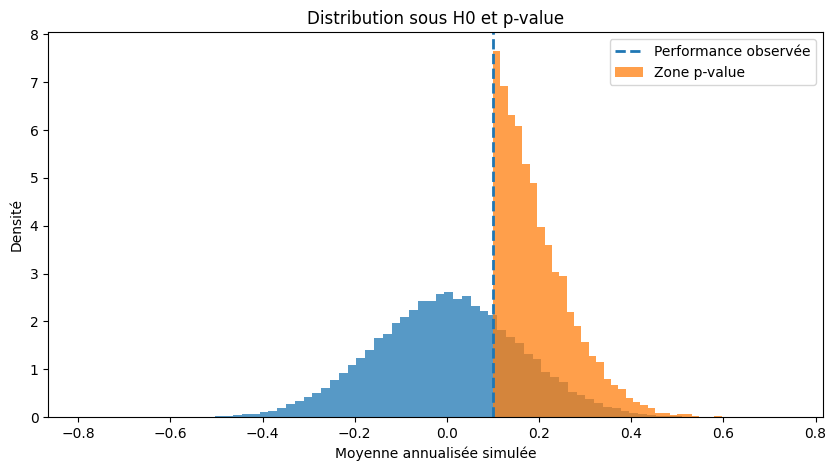

In [4]:
plt.figure(figsize=(10, 5))
plt.hist(simulated_annual_means_h0, bins=80, density=True, alpha=0.75)
plt.axvline(observed_annual_return, linestyle="--", linewidth=2, label="Performance observée")

x_tail = simulated_annual_means_h0[simulated_annual_means_h0 >= observed_annual_return]
plt.hist(x_tail, bins=40, density=True, alpha=0.75, label="Zone p-value")

plt.title("Distribution sous H0 et p-value")
plt.xlabel("Moyenne annualisée simulée")
plt.ylabel("Densité")
plt.legend()
plt.show()

## 5. Interprétation trading

Dans ce test, la question n’est pas :

> “La stratégie a-t-elle gagné de l’argent dans le passé ?”

La vraie question est :

> “Le gain observé est-il trop rare pour être expliqué raisonnablement par la chance ?”

Si la p-value est inférieure à $\alpha = 0.05$, on considère que le résultat est statistiquement significatif.

Mais attention :

> Rejeter $H_0$ ne prouve pas absolument que la stratégie est bonne.  
> Cela indique seulement que l’explication “pur hasard” devient peu crédible selon le seuil choisi.

## 6. Pourquoi la largeur de la distribution compte

Un même profit peut être significatif ou non selon la volatilité de la stratégie.

Si les rendements sont très volatils, la distribution sous $H_0$ devient plus large. Dans ce cas, un profit de +10 % peut devenir banal.

Comparons trois stratégies avec la même performance observée de +10 %, mais avec des volatilités différentes.

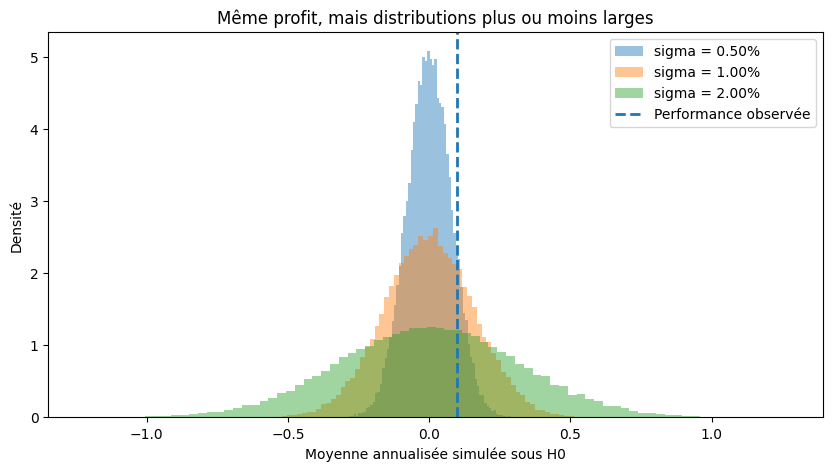

,Volatilité journalière,p-value,Verdict alpha 5%
0,0.50%,0.10474,Ne pas rejeter H0
1,1.00%,0.26310,Ne pas rejeter H0
2,2.00%,0.37662,Ne pas rejeter H0


In [5]:
def simulate_h0_distribution(N, sigma_daily, n_simulations=50_000):
    simulated = np.random.normal(0, sigma_daily, size=(n_simulations, N))
    return simulated.mean(axis=1) * TRADING_DAYS

sigmas = [0.005, 0.01, 0.02]
results = []

plt.figure(figsize=(10, 5))

for sigma in sigmas:
    dist = simulate_h0_distribution(N=N, sigma_daily=sigma)
    pv = np.mean(dist >= observed_annual_return)
    results.append({
        "Volatilité journalière": f"{sigma:.2%}",
        "p-value": pv,
        "Verdict alpha 5%": "Rejeter H0" if pv < 0.05 else "Ne pas rejeter H0"
    })
    plt.hist(dist, bins=80, density=True, alpha=0.45, label=f"sigma = {sigma:.2%}")

plt.axvline(observed_annual_return, linestyle="--", linewidth=2, label="Performance observée")
plt.title("Même profit, mais distributions plus ou moins larges")
plt.xlabel("Moyenne annualisée simulée sous H0")
plt.ylabel("Densité")
plt.legend()
plt.show()

pd.DataFrame(results)

## 7. Effet de la taille d’échantillon

Plus le nombre d’observations $N$ augmente, plus la distribution d’échantillonnage de la moyenne devient étroite.

C’est un point crucial :

> Un edge modeste peut être invisible sur peu de trades, mais devenir statistiquement clair sur un grand échantillon.

Comparons la même performance annualisée observée avec différentes tailles d’échantillon.

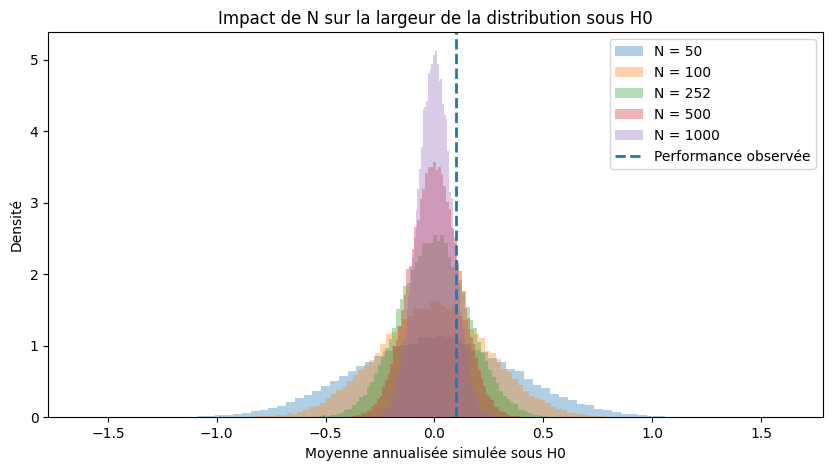

,Nombre de jours N,p-value,Verdict alpha 5%
0,50,0.38678,Ne pas rejeter H0
1,100,0.34126,Ne pas rejeter H0
2,252,0.26230,Ne pas rejeter H0
3,500,0.18778,Ne pas rejeter H0
4,1000,0.10446,Ne pas rejeter H0


In [6]:
sample_sizes = [50, 100, 252, 500, 1000]
size_results = []

plt.figure(figsize=(10, 5))

for n in sample_sizes:
    dist = simulate_h0_distribution(N=n, sigma_daily=sigma_daily)
    pv = np.mean(dist >= observed_annual_return)
    size_results.append({
        "Nombre de jours N": n,
        "p-value": pv,
        "Verdict alpha 5%": "Rejeter H0" if pv < 0.05 else "Ne pas rejeter H0"
    })
    plt.hist(dist, bins=80, density=True, alpha=0.35, label=f"N = {n}")

plt.axvline(observed_annual_return, linestyle="--", linewidth=2, label="Performance observée")
plt.title("Impact de N sur la largeur de la distribution sous H0")
plt.xlabel("Moyenne annualisée simulée sous H0")
plt.ylabel("Densité")
plt.legend()
plt.show()

pd.DataFrame(size_results)

## 8. Type I et Type II : les deux risques du trader scientifique

Un test statistique ne supprime pas l’incertitude. Il organise la prise de décision sous incertitude.

### Erreur de Type I : faux positif

On rejette $H_0$ alors que $H_0$ est vraie.

En trading :

> Tu crois avoir trouvé un edge, mais tu trades une règle qui ne doit ses profits qu’à la chance.

C’est le risque le plus dangereux pour le capital.

### Erreur de Type II : faux négatif

On ne rejette pas $H_0$ alors que la règle possède vraiment un edge.

En trading :

> Tu ignores une règle réellement profitable parce que les preuves sont insuffisantes.

## 9. Simulation des erreurs de Type I et Type II

On va simuler deux mondes :

1. un monde où $H_0$ est vraie : la stratégie n’a aucun edge ;
2. un monde où $H_A$ est vraie : la stratégie a un petit edge positif.

Ensuite on applique le même test à beaucoup de backtests simulés.

In [7]:
def one_sided_z_test_pvalue(sample, hypothesized_mean=0):
    """Test simplifié sur la moyenne. Hypothèse alternative : moyenne > hypothesized_mean."""
    mean = np.mean(sample)
    std = np.std(sample, ddof=1)
    n = len(sample)
    z = (mean - hypothesized_mean) / (std / np.sqrt(n))
    try:
        from scipy.stats import norm
        return 1 - norm.cdf(z)
    except Exception:
        import math
        return 0.5 * math.erfc(z / np.sqrt(2))


def simulate_test_decisions(true_daily_mean, N=252, sigma_daily=0.01, n_experiments=10_000, alpha=0.05):
    pvalues = []
    decisions = []
    for _ in range(n_experiments):
        sample = np.random.normal(true_daily_mean, sigma_daily, size=N)
        pv = one_sided_z_test_pvalue(sample)
        pvalues.append(pv)
        decisions.append(pv < alpha)
    return np.array(pvalues), np.array(decisions)

p_h0, reject_h0_when_h0_true = simulate_test_decisions(true_daily_mean=0)

daily_edge = 0.08 / TRADING_DAYS
p_ha, reject_h0_when_ha_true = simulate_test_decisions(true_daily_mean=daily_edge)

type_1_rate = reject_h0_when_h0_true.mean()
type_2_rate = 1 - reject_h0_when_ha_true.mean()
power = reject_h0_when_ha_true.mean()

pd.DataFrame({
    "Mesure": ["Erreur Type I", "Erreur Type II", "Puissance du test"],
    "Signification trading": [
        "Faux edge détecté alors qu'il n'existe pas",
        "Edge réel manqué par manque de preuve",
        "Probabilité de détecter l'edge réel"
    ],
    "Valeur simulée": [type_1_rate, type_2_rate, power]
})

,Mesure,Signification trading,Valeur simulée
0,Erreur Type I,Faux edge détecté alors qu'il n'existe pas,0.0486
1,Erreur Type II,Edge réel manqué par manque de preuve,0.8683
2,Puissance du test,Probabilité de détecter l'edge réel,0.1317


## 10. Visualisation des p-values dans les deux mondes

Si $H_0$ est vraie, les p-values sont souvent réparties de manière assez uniforme.

Si un edge réel existe, les p-values ont tendance à se concentrer près de zéro, ce qui augmente la probabilité de rejeter $H_0$.

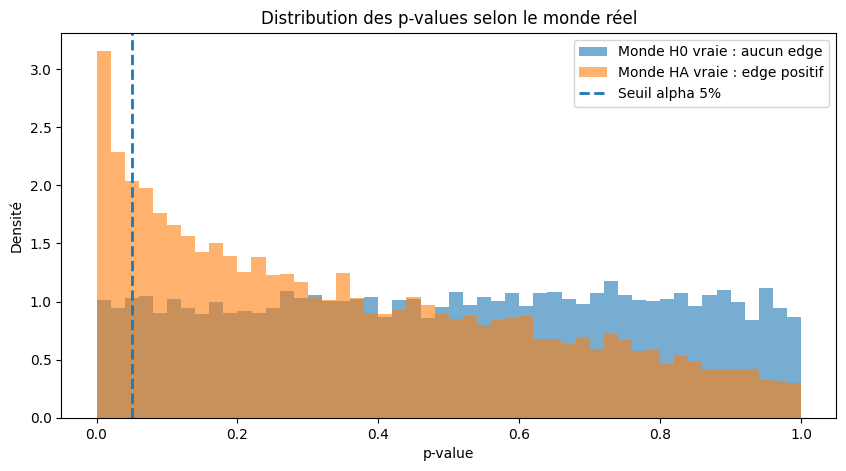

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(p_h0, bins=50, alpha=0.6, density=True, label="Monde H0 vraie : aucun edge")
plt.hist(p_ha, bins=50, alpha=0.6, density=True, label="Monde HA vraie : edge positif")
plt.axvline(alpha, linestyle="--", linewidth=2, label="Seuil alpha 5%")
plt.title("Distribution des p-values selon le monde réel")
plt.xlabel("p-value")
plt.ylabel("Densité")
plt.legend()
plt.show()

## 11. Fonction réutilisable pour tester une stratégie

La fonction ci-dessous prend une série de rendements journaliers de stratégie et renvoie :

- la moyenne journalière ;
- la moyenne annualisée ;
- la volatilité annualisée ;
- la p-value ;
- le verdict statistique.

Ce n’est pas encore un protocole complet de validation EBTA, car un vrai protocole doit gérer les biais de data mining, les coûts, le walk-forward, le bootstrap, les régimes de marché et la robustesse. Mais c’est la brique mécanique fondamentale.

In [9]:
def hypothesis_test_strategy_returns(returns, alpha=0.05, trading_days=252):
    returns = np.asarray(returns)
    returns = returns[~np.isnan(returns)]

    n = len(returns)
    daily_mean = returns.mean()
    annual_mean = daily_mean * trading_days
    annual_vol = returns.std(ddof=1) * np.sqrt(trading_days)
    p_value = one_sided_z_test_pvalue(returns, hypothesized_mean=0)
    verdict = "Rejeter H0 : résultat statistiquement significatif" if p_value < alpha else "Ne pas rejeter H0 : preuve insuffisante"

    return pd.DataFrame({
        "Métrique": [
            "Nombre d'observations",
            "Moyenne journalière",
            "Rendement annualisé moyen",
            "Volatilité annualisée",
            "p-value",
            "Alpha",
            "Verdict"
        ],
        "Valeur": [
            n,
            f"{daily_mean:.5%}",
            f"{annual_mean:.2%}",
            f"{annual_vol:.2%}",
            f"{p_value:.4f}",
            f"{alpha:.2%}",
            verdict
        ]
    })

example_strategy_returns = np.random.normal(
    loc=0.08 / TRADING_DAYS,
    scale=0.01,
    size=500
)

hypothesis_test_strategy_returns(example_strategy_returns)

,Métrique,Valeur
0,Nombre d'observations,500
1,Moyenne journalière,0.04670%
2,Rendement annualisé moyen,11.77%
3,Volatilité annualisée,16.29%
4,p-value,0.1544
5,Alpha,5.00%
6,Verdict,Ne pas rejeter H0 : preuve insuffisante


## 12. À retenir absolument

La mécanique du test d’hypothèse transforme une performance de backtest en question probabiliste :

> Si ma règle n’a aucun edge, quelle est la probabilité d’obtenir un résultat au moins aussi bon que celui observé ?

La p-value est donc une **mesure de surprise** par rapport à $H_0$.

### Synthèse EBTA

- Un profit historique seul n’est pas une preuve.
- Le test commence par supposer que la règle n’a aucun talent.
- La distribution sous $H_0$ représente ce que la chance peut produire.
- La p-value mesure la rareté du résultat observé sous $H_0$.
- Si p-value < alpha, on rejette $H_0$.
- Rejeter $H_0$ ne prouve pas l’edge de manière absolue, mais rend l’explication “chance pure” moins crédible.
- Plus la volatilité est élevée, plus la preuve doit être forte.
- Plus l’échantillon est grand, plus le test devient puissant.
- L’erreur de Type I est le danger principal : croire à un edge qui n’existe pas.

## Formule mentale simple

> Backtest profitable ≠ edge validé.  
> Backtest profitable + p-value faible + protocole robuste = début de preuve exploitable.